In [3]:
import ultralytics
from ultralytics import YOLO
print('ultralytics version:', ultralytics.__version__)

model = YOLO('yolo26n.pt')
print('yolo model loaded succesfully')

ultralytics version: 8.4.143
yolo model loaded succesfully


In [4]:
from pathlib import Path
import yaml

data_yaml = Path('/home/jyothish/amrit/amrittt/Checking/processed/data.yaml')

with open(data_yaml, 'r') as f:
    data = yaml.safe_load(f)

print("Dataset path :", data["path"])
print("Train path   :", data["train"])
print("Val path     :", data["val"])
print("Test path    :", data["test"])
print("Classes      :", data["names"])
print("No. classes  :", len(data["names"])) 

Dataset path : /home/jyothish/amrit/amrittt/Checking/processed
Train path   : train/images
Val path     : valid/images
Test path    : test/images
Classes      : {0: 'fire', 1: 'other', 2: 'smoke'}
No. classes  : 3


In [7]:
dataset_path = Path('/home/jyothish/amrit/amrittt/Checking/processed')

for split in ['train', 'valid','test']:
    image_dir = dataset_path/ split / 'images'
    label_dir = dataset_path/ split / 'labels'

    images = list(image_dir.glob('*'))
    labels = list(label_dir.glob('*.txt'))

    print(f"\n{split.upper()}")
    print("-" * 30)
    print("Images :", len(images))
    print("Labels :", len(labels))


TRAIN
------------------------------
Images : 6254
Labels : 6254

VALID
------------------------------
Images : 1784
Labels : 1784

TEST
------------------------------
Images : 901
Labels : 901


In [9]:
image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

for split in ["train", "valid", "test"]:
    image_dir = dataset_path / split / "images"
    label_dir = dataset_path / split / "labels"

    image_stems = {
        p.stem for p in image_dir.iterdir()
        if p.suffix.lower() in image_extensions
    }

    label_stems = {
        p.stem for p in label_dir.glob("*.txt")
    }

    missing_labels = image_stems - label_stems
    missing_images = label_stems - image_stems

    print(f"\n{split.upper()}")
    print("-" * 30)
    print("Images without labels :", len(missing_labels))
    print("Labels without images :", len(missing_images))

    if missing_labels:
        print("Example missing labels:", list(missing_labels)[:5])

    if missing_images:
        print("Example missing images:", list(missing_images)[:5])


TRAIN
------------------------------
Images without labels : 0
Labels without images : 0

VALID
------------------------------
Images without labels : 0
Labels without images : 0

TEST
------------------------------
Images without labels : 0
Labels without images : 0


In [10]:
valid_classes = {0, 1, 2}
invalid_labels = []
total_boxes = 0
class_counts = {0: 0, 1: 0, 2: 0}

for split in ["train", "valid", "test"]:
    label_dir = dataset_path / split / "labels"

    for label_file in label_dir.glob("*.txt"):
        with open(label_file, "r") as f:
            for line_no, line in enumerate(f, start=1):
                line = line.strip()

                if not line:
                    continue

                parts = line.split()

                # YOLO format: class x_center y_center width height
                if len(parts) != 5:
                    invalid_labels.append(
                        (label_file.name, line_no, "Wrong number of values")
                    )
                    continue

                try:
                    cls = int(parts[0])
                    coords = list(map(float, parts[1:]))

                    if cls not in valid_classes:
                        invalid_labels.append(
                            (label_file.name, line_no, f"Invalid class: {cls}")
                        )

                    if not all(0 <= x <= 1 for x in coords):
                        invalid_labels.append(
                            (label_file.name, line_no, "Coordinates outside [0,1]")
                        )

                    class_counts[cls] = class_counts.get(cls, 0) + 1
                    total_boxes += 1

                except ValueError:
                    invalid_labels.append(
                        (label_file.name, line_no, "Non-numeric value")
                    )

print("Total bounding boxes:", total_boxes)
print("\nClass distribution:")
print("0 (fire)  :", class_counts[0])
print("1 (other) :", class_counts[1])
print("2 (smoke) :", class_counts[2])

print("\nInvalid annotations:", len(invalid_labels))

if invalid_labels:
    print("\nExamples:")
    for item in invalid_labels[:10]:
        print(item)

Total bounding boxes: 24091

Class distribution:
0 (fire)  : 13914
1 (other) : 4845
2 (smoke) : 5332

Invalid annotations: 0


In [14]:
import cv2
import matplotlib.pyplot as plt
import ipywidgets as widgets


In [17]:

CLASS_NAMES = {
    0: "fire",
    1: "other",
    2: "smoke"
}


def get_images(split):
    image_dir = dataset_path / split / "images"

    return sorted([
        p for p in image_dir.iterdir()
        if p.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp", ".webp"]
    ])


def show_dataset_image(split, index):

    images = get_images(split)

    image_path = images[index]

    label_dir = dataset_path / split / "labels"
    label_path = label_dir / f"{image_path.stem}.txt"

    image = cv2.imread(str(image_path))

    if image is None:
        print("Could not read:", image_path)
        return

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    height, width = image.shape[:2]

    annotated_image = image.copy()

    annotations = []

    if label_path.exists():

        with open(label_path, "r") as f:
            lines = f.readlines()

        for line in lines:

            parts = line.strip().split()

            if len(parts) != 5:
                continue

            class_id = int(parts[0])

            x_center = float(parts[1]) * width
            y_center = float(parts[2]) * height
            box_width = float(parts[3]) * width
            box_height = float(parts[4]) * height

            x1 = int(x_center - box_width / 2)
            y1 = int(y_center - box_height / 2)
            x2 = int(x_center + box_width / 2)
            y2 = int(y_center + box_height / 2)

            class_name = CLASS_NAMES.get(
                class_id,
                f"unknown_{class_id}"
            )

            annotations.append(
                f"{class_id} → {class_name}"
            )

            cv2.rectangle(
                annotated_image,
                (x1, y1),
                (x2, y2),
                (255, 0, 0),
                2
            )

            cv2.putText(
                annotated_image,
                class_name,
                (x1, max(y1 - 10, 20)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.7,
                (255, 0, 0),
                2
            )

    # Display image
    plt.figure(figsize=(12, 8))
    plt.imshow(annotated_image)
    plt.axis("off")
    plt.title(
        f"{split.upper()} | "
        f"{index + 1}/{len(images)} | "
        f"{image_path.name}"
    )
    plt.show()

    # Display label information
    print("=" * 70)
    print("IMAGE:", image_path.name)
    print("LABEL:", label_path.name)
    print("=" * 70)

    if label_path.exists():
        print(label_path.read_text())
    else:
        print("Label file not found!")

    print("\nCLASS INFORMATION")
    print("-" * 70)

    if annotations:
        for annotation in annotations:
            print(annotation)
    else:
        print("No annotations")

In [ ]:
split_dropdown = widgets.Dropdown(
    options=["train", "valid", "test"],
    value="train",
    description="Split:"
)

index_slider = widgets.IntSlider(
    min=0,
    max=len(get_images("train")) - 1,
    step=1,
    value=0,
    description="Image:"
)


def update_slider(*args):

    split = split_dropdown.value
    images = get_images(split)

    index_slider.max = len(images) - 1
    index_slider.value = min(index_slider.value, len(images) - 1)


split_dropdown.observe(update_slider, names="value")


def interactive_viewer(split, index):

    show_dataset_image(split, index)


widgets.interact(
    interactive_viewer,
    split=split_dropdown,
    index=index_slider
);

interactive(children=(Dropdown(description='Split:', options=('train', 'valid', 'test'), value='train'), IntSl…

In [19]:
from collections import Counter
from PIL import Image
import matplotlib.pyplot as plt

image_sizes = Counter()

for split in ["train", "valid", "test"]:

    image_dir = dataset_path / split / "images"

    for image_path in image_dir.iterdir():

        if image_path.suffix.lower() not in [
            ".jpg", ".jpeg", ".png", ".bmp", ".webp"
        ]:
            continue

        try:
            with Image.open(image_path) as img:
                image_sizes[img.size] += 1

        except Exception as e:
            print("Could not read:", image_path)


print("Unique image sizes:", len(image_sizes))

print("\nMost common image sizes:")
for size, count in image_sizes.most_common(15):
    print(f"{size}: {count}")

Unique image sizes: 1

Most common image sizes:
(416, 416): 8939


In [20]:
import torch

print("PyTorch version :", torch.__version__)
print("CUDA available  :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU             :", torch.cuda.get_device_name(0))
    print("CUDA version    :", torch.version.cuda)
    print("GPU count       :", torch.cuda.device_count())

PyTorch version : 2.6.0+cu124
CUDA available  : True
GPU             : NVIDIA A10
CUDA version    : 12.4
GPU count       : 1


In [21]:
results = model.train(
    data="/home/jyothish/amrit/amrittt/Checking/processed/data.yaml",
    epochs=100,
    imgsz=416,
    batch=32,
    device=0,
    workers=8,
    project="/home/jyothish/amrit/amrittt/Checking/runs",
    name="yolo26n_fire_baseline",
    pretrained=True,
    seed=42,
    plots=True
)

New https://pypi.org/project/ultralytics/8.4.157 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.143 🚀 Python-3.12.12 torch-2.6.0+cu124 CUDA:0 (NVIDIA A10, 22516MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/jyothish/amrit/amrittt/Checking/processed/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup

In [23]:
import pandas as pd
run_dir = Path(
    "/home/jyothish/amrit/amrittt/Checking/runs/yolo26n_fire_baseline"
)

results_file = run_dir / "results.csv"

print("Run directory :", run_dir)
print("Results file  :", results_file)
print("Best model    :", run_dir / "weights" / "best.pt")
print("Last model    :", run_dir / "weights" / "last.pt")

results_df = pd.read_csv(results_file)

print("\nAvailable metrics:")
print(results_df.columns.tolist())

print("\nLast 5 epochs:")
display(results_df.tail())

Run directory : /home/jyothish/amrit/amrittt/Checking/runs/yolo26n_fire_baseline
Results file  : /home/jyothish/amrit/amrittt/Checking/runs/yolo26n_fire_baseline/results.csv
Best model    : /home/jyothish/amrit/amrittt/Checking/runs/yolo26n_fire_baseline/weights/best.pt
Last model    : /home/jyothish/amrit/amrittt/Checking/runs/yolo26n_fire_baseline/weights/last.pt

Available metrics:
['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/l1_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/l1_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']

Last 5 epochs:


,epoch,time,train/box_loss,train/cls_loss,train/l1_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/l1_loss,lr/pg0,lr/pg1,lr/pg2
95,96,1930.00,1.49708,1.15251,0.01931,0.54084,0.43038,0.44488,0.21132,1.87562,1.83728,0.02644,0.000085,0.000085,0.000085
96,97,1950.10,1.50259,1.14246,0.01917,0.55430,0.42352,0.44495,0.21167,1.87977,1.83508,0.02647,0.000071,0.000071,0.000071
97,98,1969.98,1.49465,1.14677,0.01915,0.55626,0.42518,0.44471,0.21138,1.87392,1.84520,0.02641,0.000057,0.000057,0.000057
98,99,1990.02,1.49300,1.13533,0.01892,0.55106,0.42815,0.44463,0.21101,1.87944,1.83911,0.02653,0.000043,0.000043,0.000043
99,100,2009.79,1.49266,1.13178,0.01886,0.55128,0.42908,0.44394,0.21020,1.88087,1.83529,0.02654,0.000028,0.000028,0.000028


In [24]:
best_map_idx = results_df["metrics/mAP50-95(B)"].idxmax()

best_row = results_df.loc[best_map_idx]

print("Best epoch:", int(best_row["epoch"]) + 1)

print("\nBest metrics:")
print(
    f"Precision   : {best_row['metrics/precision(B)']:.4f}"
)

print(
    f"Recall      : {best_row['metrics/recall(B)']:.4f}"
)

print(
    f"mAP50       : {best_row['metrics/mAP50(B)']:.4f}"
)

print(
    f"mAP50-95    : {best_row['metrics/mAP50-95(B)']:.4f}"
)

Best epoch: 55

Best metrics:
Precision   : 0.5379
Recall      : 0.4522
mAP50       : 0.4721
mAP50-95    : 0.2242


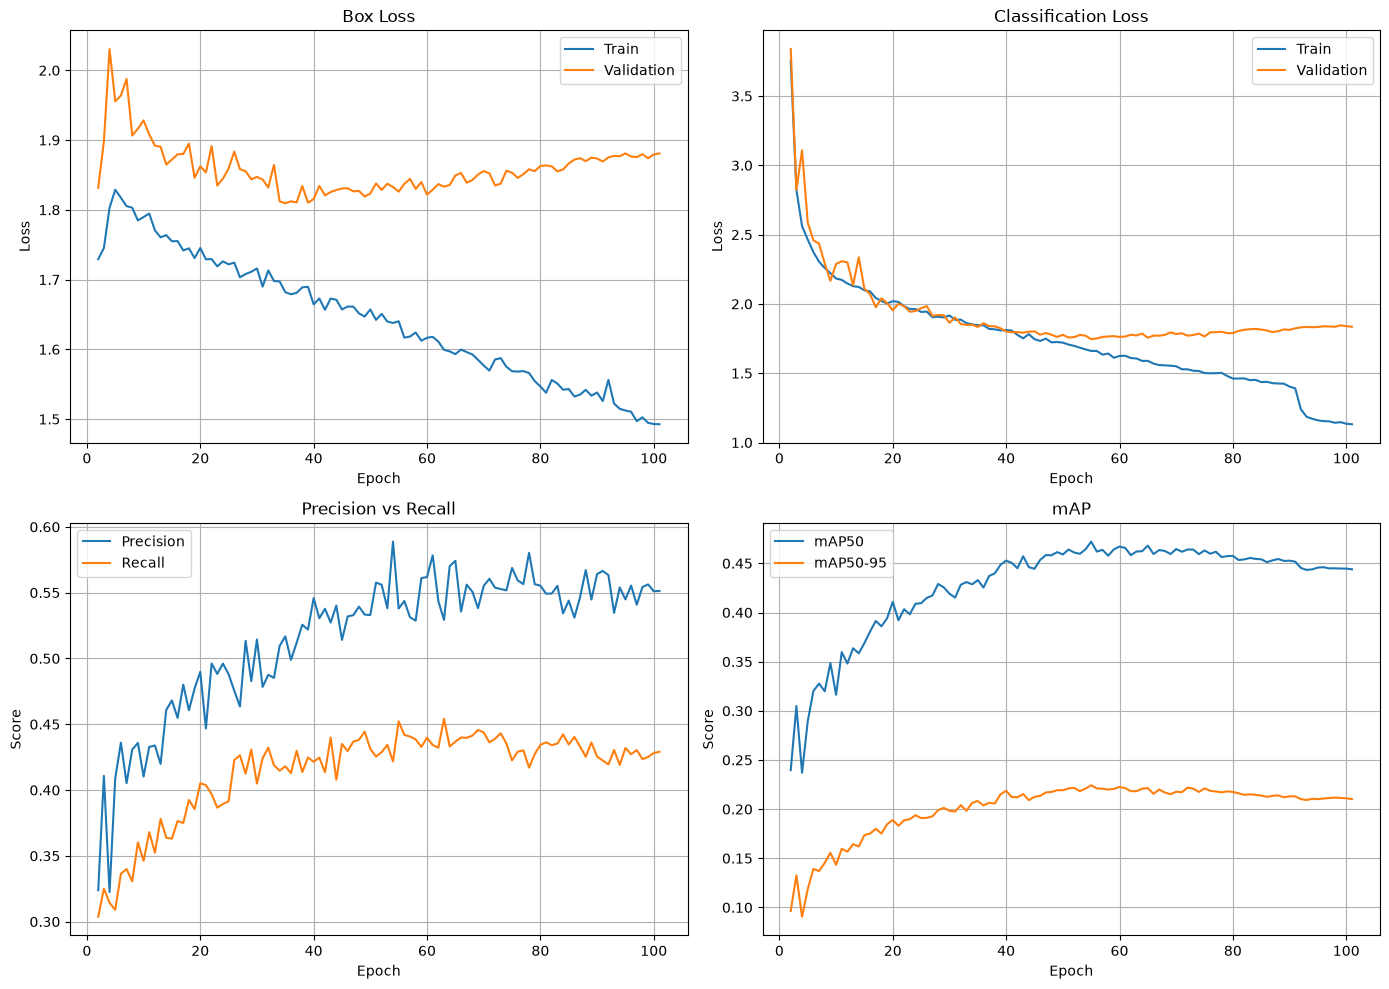

In [25]:
epochs = results_df["epoch"] + 1

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Box loss
axes[0, 0].plot(
    epochs,
    results_df["train/box_loss"],
    label="Train"
)

axes[0, 0].plot(
    epochs,
    results_df["val/box_loss"],
    label="Validation"
)

axes[0, 0].set_title("Box Loss")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Loss")
axes[0, 0].legend()
axes[0, 0].grid(True)


# Classification loss
axes[0, 1].plot(
    epochs,
    results_df["train/cls_loss"],
    label="Train"
)

axes[0, 1].plot(
    epochs,
    results_df["val/cls_loss"],
    label="Validation"
)

axes[0, 1].set_title("Classification Loss")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Loss")
axes[0, 1].legend()
axes[0, 1].grid(True)


# Precision and Recall
axes[1, 0].plot(
    epochs,
    results_df["metrics/precision(B)"],
    label="Precision"
)

axes[1, 0].plot(
    epochs,
    results_df["metrics/recall(B)"],
    label="Recall"
)

axes[1, 0].set_title("Precision vs Recall")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Score")
axes[1, 0].legend()
axes[1, 0].grid(True)


# mAP
axes[1, 1].plot(
    epochs,
    results_df["metrics/mAP50(B)"],
    label="mAP50"
)

axes[1, 1].plot(
    epochs,
    results_df["metrics/mAP50-95(B)"],
    label="mAP50-95"
)

axes[1, 1].set_title("mAP")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("Score")
axes[1, 1].legend()
axes[1, 1].grid(True)


plt.tight_layout()
plt.show()

In [26]:
best_model = YOLO(
    "/home/jyothish/amrit/amrittt/Checking/runs/"
    "yolo26n_fire_baseline/weights/best.pt"
)

val_results = best_model.val(
    data="/home/jyothish/amrit/amrittt/Checking/processed/data.yaml",
    split="val",
    imgsz=416,
    batch=32,
    device=0,
    plots=True
)

print("\nOverall Metrics")
print("-" * 50)
print(f"Precision : {val_results.box.mp:.4f}")
print(f"Recall    : {val_results.box.mr:.4f}")
print(f"mAP50     : {val_results.box.map50:.4f}")
print(f"mAP50-95  : {val_results.box.map:.4f}")

print("\nClass-wise Results")
print("-" * 50)

for i, name in enumerate(best_model.names.values()):
    print(
        f"{name:10s} | "
        f"Precision: {val_results.box.p[i]:.4f} | "
        f"Recall: {val_results.box.r[i]:.4f} | "
        f"mAP50: {val_results.box.ap50[i]:.4f} | "
        f"mAP50-95: {val_results.box.ap[i]:.4f}"
    )

Ultralytics 8.4.143 🚀 Python-3.12.12 torch-2.6.0+cu124 CUDA:0 (NVIDIA A10, 22516MiB)
YOLO26n summary (fused): 120 layers, 2,375,421 parameters, 0 gradients, 5.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1803.2±533.9 MB/s, size: 24.9 KB)
val: Scanning /home/jyothish/amrit/amrittt/Checking/processed/valid/labels.cache... 1784 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1784/1784 623.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 56/56 11.1it/s 5.1s0.2s
                   all       1784       4804      0.538      0.453      0.472      0.224
                  fire       1539       2797      0.621      0.606      0.636      0.325
                 other        434        953      0.432      0.328       0.32      0.127
                 smoke        718       1054      0.561      0.425       0.46      0.221
Speed: 0.3ms preprocess, 0.7ms inference, 0.0ms loss, 0.5ms postprocess per image
Results sav

In [27]:
test_results = best_model.val(
    data="/home/jyothish/amrit/amrittt/Checking/processed/data.yaml",
    split="test",
    imgsz=416,
    batch=32,
    device=0,
    plots=True
)

print("\nTest Set Metrics")
print("-" * 50)

print(f"Precision : {test_results.box.mp:.4f}")
print(f"Recall    : {test_results.box.mr:.4f}")
print(f"mAP50     : {test_results.box.map50:.4f}")
print(f"mAP50-95  : {test_results.box.map:.4f}")

print("\nClass-wise Test Results")
print("-" * 50)

for i, name in enumerate(best_model.names.values()):
    print(
        f"{name:10s} | "
        f"Precision: {test_results.box.p[i]:.4f} | "
        f"Recall: {test_results.box.r[i]:.4f} | "
        f"mAP50: {test_results.box.ap50[i]:.4f} | "
        f"mAP50-95: {test_results.box.ap[i]:.4f}"
    )

Ultralytics 8.4.143 🚀 Python-3.12.12 torch-2.6.0+cu124 CUDA:0 (NVIDIA A10, 22516MiB)
YOLO26n summary (fused): 120 layers, 2,375,421 parameters, 0 gradients, 5.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 332.1±377.5 MB/s, size: 21.2 KB)
val: Scanning /home/jyothish/amrit/amrittt/Checking/processed/test/labels... 901 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 901/901 3.4Kit/s 0.3s0.1ss
val: New cache created: /home/jyothish/amrit/amrittt/Checking/processed/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 29/29 8.9it/s 3.3s<0.1s
                   all        901       2440      0.546      0.438      0.457      0.215
                  fire        774       1427      0.598      0.587      0.602      0.306
                 other        222        485      0.426      0.282      0.274      0.107
                 smoke        364        528      0.614      0.445      0.495      0.232
Speed: 0.4m

Confusion matrix path: /home/jyothish/amrit/amrittt/Checking/runs/detect/val-2/confusion_matrix.png
Exists: True


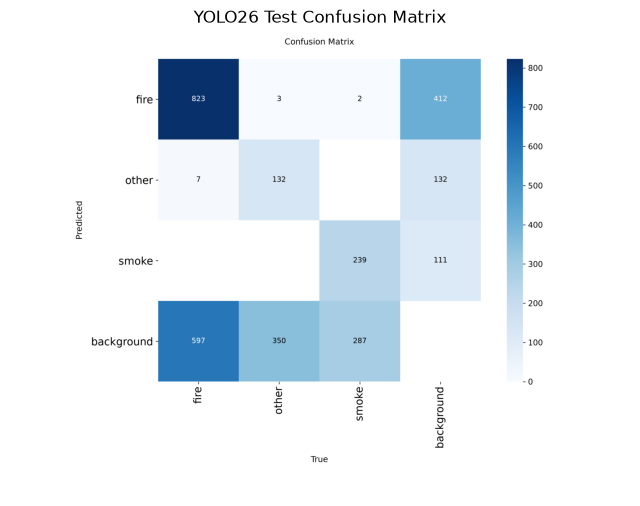

In [28]:
test_run_dir = Path(
    "/home/jyothish/amrit/amrittt/Checking/runs/detect/val-2"
)

cm_path = test_run_dir / "confusion_matrix.png"

print("Confusion matrix path:", cm_path)
print("Exists:", cm_path.exists())

if cm_path.exists():

    cm_image = Image.open(cm_path)

    plt.figure(figsize=(8, 7))
    plt.imshow(cm_image)
    plt.axis("off")
    plt.title("YOLO26 Test Confusion Matrix")
    plt.show()
else:
    print("Confusion matrix not found.")

In [29]:
prediction_dir = Path(
    "/home/jyothish/amrit/amrittt/Checking/runs/test_predictions"
)

prediction_results = best_model.predict(
    source="/home/jyothish/amrit/amrittt/Checking/processed/test/images",
    imgsz=416,
    conf=0.25,
    iou=0.7,
    device=0,
    save=True,
    save_txt=True,
    save_conf=True,
    project=str(prediction_dir.parent),
    name=prediction_dir.name,
    exist_ok=True
)

print("Prediction completed.")
print("Results saved to:", prediction_dir)


image 1/901 /home/jyothish/amrit/amrittt/Checking/processed/test/images/large_-1001-_jpg.rf.4dbc5013decd3e7883da55783c524999.jpg: 416x416 2 fires, 8.3ms
image 2/901 /home/jyothish/amrit/amrittt/Checking/processed/test/images/large_-1007-_jpg.rf.65801d9caeecd0f7f7767d0a80828ebc.jpg: 416x416 1 fire, 9.6ms
image 3/901 /home/jyothish/amrit/amrittt/Checking/processed/test/images/large_-1015-_jpg.rf.82c0f427f9e58165e7d68ec4f65f0790.jpg: 416x416 1 fire, 1 smoke, 8.5ms
image 4/901 /home/jyothish/amrit/amrittt/Checking/processed/test/images/large_-1016-_jpg.rf.2a636281d889ea30f165e1a25c78f3de.jpg: 416x416 1 fire, 8.5ms
image 5/901 /home/jyothish/amrit/amrittt/Checking/processed/test/images/large_-1026-_jpg.rf.544d1c2a1adf789d3d0e44b2cd99c904.jpg: 416x416 1 fire, 9.2ms
image 6/901 /home/jyothish/amrit/amrittt/Checking/processed/test/images/large_-1043-_jpg.rf.08291a4cdfaf3bc26e7e2877066949b5.jpg: 416x416 1 fire, 1 smoke, 9.0ms
image 7/901 /home/jyothish/amrit/amrittt/Checking/processed/test/ima

In [ ]:
from IPython.display import clear_output
test_image_dir = dataset_path / "test" / "images"
test_label_dir = dataset_path / "test" / "labels"

prediction_label_dir = (
    Path("/home/jyothish/amrit/amrittt/Checking/runs/test_predictions")
    / "labels"
)

class_names = {
    0: "fire",
    1: "other",
    2: "smoke"
}

image_extensions = {
    ".jpg", ".jpeg", ".png", ".bmp", ".webp"
}

test_images = sorted([
    p for p in test_image_dir.iterdir()
    if p.suffix.lower() in image_extensions
])

print("Test images:", len(test_images))
print("Prediction labels:", len(list(prediction_label_dir.glob("*.txt"))))


def read_yolo_labels(label_path):
    
    labels = []

    if not label_path.exists():
        return labels

    with open(label_path, "r") as f:
        for line in f:

            parts = line.strip().split()

            if len(parts) < 5:
                continue

            class_id = int(parts[0])

            values = list(map(float, parts[1:5]))

            confidence = (
                float(parts[5])
                if len(parts) >= 6
                else None
            )

            labels.append(
                (
                    class_id,
                    values,
                    confidence
                )
            )

    return labels


def draw_boxes(image, labels):

    image = image.copy()

    height, width = image.shape[:2]

    for class_id, values, confidence in labels:

        x_center, y_center, box_width, box_height = values

        x_center *= width
        y_center *= height
        box_width *= width
        box_height *= height

        x1 = int(x_center - box_width / 2)
        y1 = int(y_center - box_height / 2)
        x2 = int(x_center + box_width / 2)
        y2 = int(y_center + box_height / 2)

        class_name = class_names.get(
            class_id,
            f"unknown_{class_id}"
        )

        label = class_name

        if confidence is not None:
            label += f" {confidence:.2f}"

        cv2.rectangle(
            image,
            (x1, y1),
            (x2, y2),
            (255, 0, 0),
            2
        )

        cv2.putText(
            image,
            label,
            (x1, max(y1 - 8, 15)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (255, 0, 0),
            2
        )

    return image


# Widgets
index_slider = widgets.IntSlider(
    value=0,
    min=0,
    max=len(test_images) - 1,
    step=1,
    description="Image:",
    continuous_update=False
)

output = widgets.Output()


def show_comparison(index):

    image_path = test_images[index]

    gt_label_path = (
        test_label_dir /
        f"{image_path.stem}.txt"
    )

    pred_label_path = (
        prediction_label_dir /
        f"{image_path.stem}.txt"
    )

    image = cv2.imread(str(image_path))

    if image is None:
        return

    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    gt_labels = read_yolo_labels(
        gt_label_path
    )

    pred_labels = read_yolo_labels(
        pred_label_path
    )

    gt_image = draw_boxes(
        image,
        gt_labels
    )

    pred_image = draw_boxes(
        image,
        pred_labels
    )

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(16, 7)
    )

    axes[0].imshow(gt_image)
    axes[0].set_title(
        f"GROUND TRUTH\n{len(gt_labels)} objects"
    )
    axes[0].axis("off")

    axes[1].imshow(pred_image)
    axes[1].set_title(
        f"YOLO26 PREDICTION\n{len(pred_labels)} objects"
    )
    axes[1].axis("off")

    plt.suptitle(
        f"{index + 1}/{len(test_images)} — {image_path.name}"
    )

    plt.tight_layout()
    plt.show()

    print("=" * 80)
    print("IMAGE:", image_path.name)
    print("=" * 80)

    print("\nGround Truth:")
    for class_id, _, _ in gt_labels:
        print(
            f"  {class_id} → "
            f"{class_names.get(class_id, 'unknown')}"
        )

    print("\nYOLO26 Prediction:")
    for class_id, _, confidence in pred_labels:
        print(
            f"  {class_id} → "
            f"{class_names.get(class_id, 'unknown')} "
            f"(confidence={confidence:.3f})"
        )


def update_view(change):

    with output:
        clear_output(wait=True)
        show_comparison(change["new"])


index_slider.observe(
    update_view,
    names="value"
)

display(
    widgets.VBox([
        index_slider,
        output
    ])
)

# Show first image
with output:
    show_comparison(0)

Test images: 901
Prediction labels: 842
